In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
base_path = r"E:\kdt_0900_sal\ml\resource\dataset"
file_name = r"telecom_customer.csv"
file_path = os.path.join(base_path, file_name)

In [4]:
df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 텔레콤 고객 이탈 데이터셋
[텔레콤 고객 이탈 데이터셋](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## 텔레콤 고객 이탈 데이터셋 컬럼
| 컬럼명 | 설명 |
| :--- | :--- |
| customerID | 고객 고유 식별자 |
| gender | 성별 |
| SeniorCitizen | 고령자 여부 (65세 이상) |
| Partner | 배우자 유무 |
| Dependents | 부양가족 유무 |
| tenure | 서비스 가입 기간 (개월 수) |
| PhoneService | 전화 서비스 가입 여부 |
| MultipleLines | 다중 회선 사용 여부 |
| InternetService | 인터넷 서비스 제공 방식 |
| OnlineSecurity | 온라인 보안 서비스 이용 여부 |
| OnlineBackup | 온라인 백업 서비스 이용 여부 |
| DeviceProtection | 기기 보호 옵션 이용 여부 |
| TechSupport | 전담 기술 지원 서비스 이용 여부 |
| StreamingTV | 스트리밍 TV 서비스 이용 여부 |
| StreamingMovies | 스트리밍 영화 서비스 이용 여부 |
| Contract | 계약 형태 (월 단위, 1년, 2년) |
| PaperlessBilling | 전자 청구서 이용 여부 |
| PaymentMethod | 결제 수단 |
| MonthlyCharges | 월 청구 금액 |
| TotalCharges | 누적 총 청구 금액 |
| Churn | 고객 이탈 여부 (예측 대상) |

In [5]:
telecom_df = df.drop("customerID", axis=1)
telecom_df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [6]:
telecom_df["TotalCharges"] = telecom_df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True).astype(float)

In [7]:
telecom_df["TotalCharges"] = telecom_df["TotalCharges"].fillna(telecom_df["TotalCharges"].median())

In [8]:
telecom_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

## 랜덤포레스트 실습

In [9]:
telecom_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## 파생변수 생성

In [12]:
telecom_df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [15]:
# Partner, Dependents
telecom_df["FamilySize"] = 1 + (telecom_df["Partner"] == "Yes").astype(int) + (telecom_df["Dependents"] == "Yes").astype(int)

In [17]:
telecom_df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilySize
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2


In [19]:
service_columns = [
    "PhoneService",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# 총 서비스를 가입한 수
telecom_df["TotalServices"] = (telecom_df[service_columns] == "Yes").sum(axis=1)

In [23]:
telecom_df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilySize,TotalServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2,1


In [24]:
telecom_df["Churn"] = (telecom_df["Churn"] == "Yes").astype(int)

<Axes: xlabel='TotalServices', ylabel='Churn'>

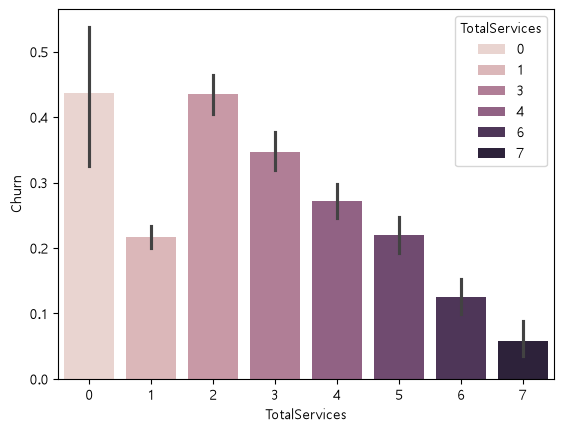

In [25]:
# 총 서비스 vs 이탈률
sns.barplot(telecom_df, x="TotalServices", y="Churn", hue="TotalServices")

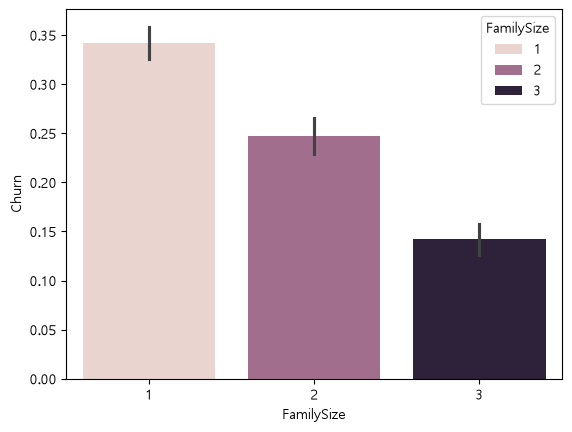

In [28]:
sns.barplot(telecom_df, x="FamilySize", y="Churn", hue="FamilySize")
plt.show()

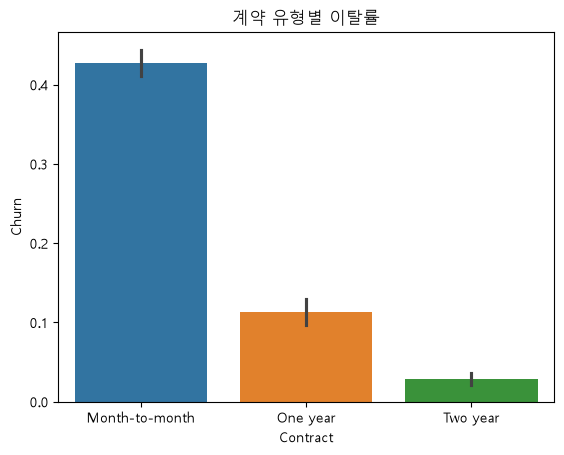

In [30]:
sns.barplot(telecom_df, x="Contract", y="Churn", hue="Contract")
plt.title("계약 유형별 이탈률")
plt.show()

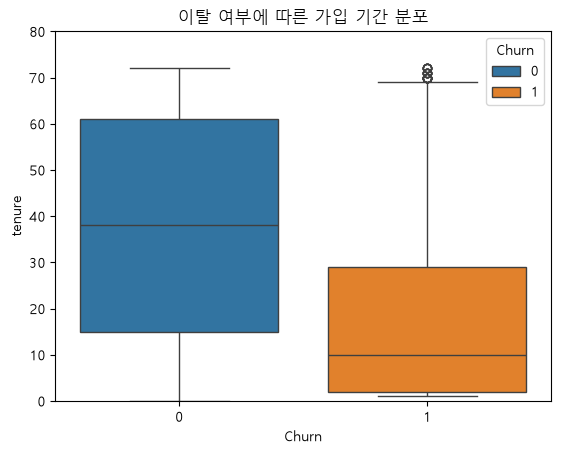

In [33]:
sns.boxplot(telecom_df, x="Churn", y="tenure", hue="Churn")
plt.title("이탈 여부에 따른 가입 기간 분포")
plt.ylim(0, 80)
plt.show()

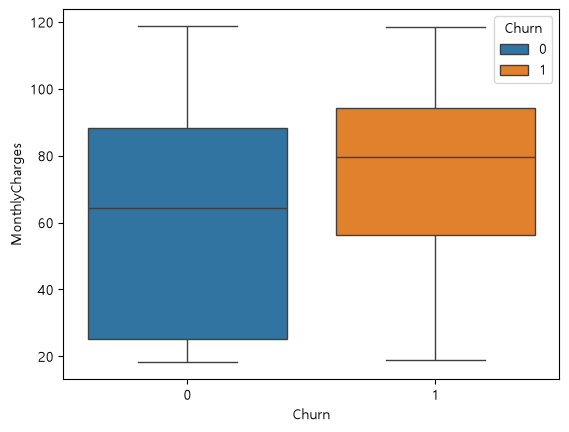

In [34]:
sns.boxplot(telecom_df, x="Churn", y="MonthlyCharges", hue="Churn")
plt.show()

In [36]:
X = telecom_df.drop("Churn", axis=1)
y = telecom_df["Churn"]

In [39]:
for col in X.columns:
    # print(X[col].unique())
    print(f"{col:<20} 개수: {X[col].nunique()}개")

gender               개수: 2개
SeniorCitizen        개수: 2개
Partner              개수: 2개
Dependents           개수: 2개
tenure               개수: 73개
PhoneService         개수: 2개
MultipleLines        개수: 3개
InternetService      개수: 3개
OnlineSecurity       개수: 3개
OnlineBackup         개수: 3개
DeviceProtection     개수: 3개
TechSupport          개수: 3개
StreamingTV          개수: 3개
StreamingMovies      개수: 3개
Contract             개수: 3개
PaperlessBilling     개수: 2개
PaymentMethod        개수: 4개
MonthlyCharges       개수: 1585개
TotalCharges         개수: 6531개
FamilySize           개수: 3개
TotalServices        개수: 8개


In [41]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   FamilySize                             7043 non-null   int64  
 5   TotalServices                          7043 non-null   int64  
 6   gender_Male                            7043 non-null   int64  
 7   Partner_Yes                            7043 non-null   int64  
 8   Dependents_Yes                         7043 non-null   int64  
 9   PhoneService_Yes                       7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  MultipleLines_Y

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5634, 32) (1409, 32) (5634,) (1409,)


## 2단계, 모델 준비

In [43]:
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=2026)

In [44]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=2026)

In [46]:
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

In [47]:
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(1409,))

In [48]:
rf.score(X_test, y_pred)

1.0

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



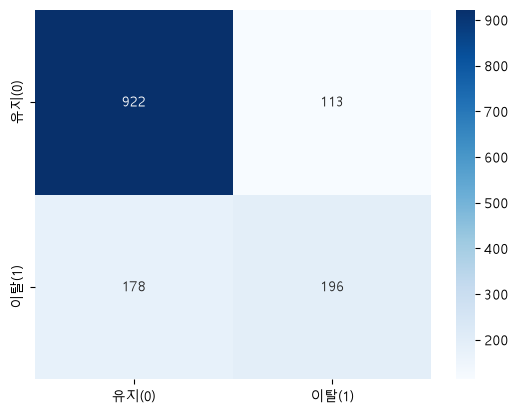

In [57]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xticks([0.5, 1.5], ["유지(0)", "이탈(1)"])
plt.yticks([0.5, 1.5], ["유지(0)", "이탈(1)"])
plt.show()

In [59]:
feature_imp = pd.DataFrame({
    "Features": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_imp

,Features,Importance
3,TotalCharges,0.180574
1,tenure,0.171487
2,MonthlyCharges,0.154503
5,TotalServices,0.040994
12,InternetService_Fiber optic,0.036399
27,Contract_Two year,0.035625
30,PaymentMethod_Electronic check,0.031759
6,gender_Male,0.027364
28,PaperlessBilling_Yes,0.026399
4,FamilySize,0.023675


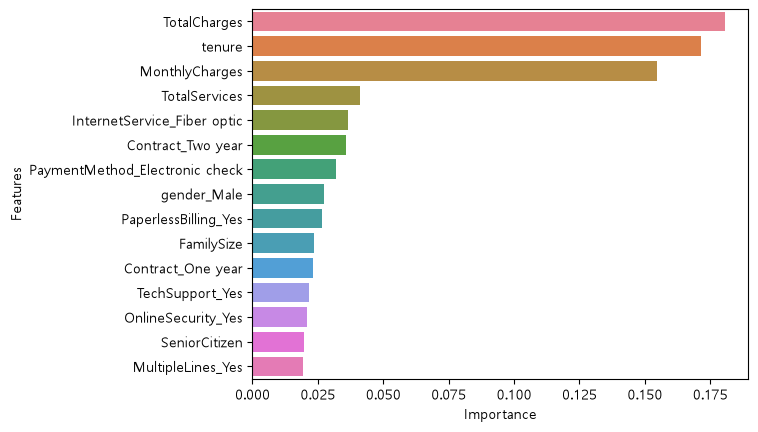

In [62]:
sns.barplot(feature_imp.head(15), x="Importance", y="Features", hue="Features")

plt.show()